In [1]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom as dcm
import math
import os

### Plotting dose and LET as function of depth
Done using water phantom

In [37]:
path = r"C:\Users\bhaan\Downloads\Unrestricted beam plan - LET data and RTStruct\roi_let_dose_coords_waterphantom.csv"
data_waterphantom = pd.read_csv(path)
print(data_waterphantom.head())

      x_mm     y_mm    z_mm  LET_keV_per_um  Dose_GyRBE
0 -12.8404 -108.629 -236.75        2.261331    0.409376
1 -12.5404 -108.629 -236.75        2.307082    0.381484
2 -12.2404 -108.629 -236.75        2.495038    0.379533
3 -11.9404 -108.629 -236.75        2.341327    0.374497
4 -11.6404 -108.629 -236.75        2.532819    0.373728


In [38]:
#Find middle x and y
x_mid = np.unique(data_waterphantom['x_mm'])[round(len(np.unique(data_waterphantom['x_mm']))/2)]
z_mid = np.unique(data_waterphantom['z_mm'])[round(len(np.unique(data_waterphantom['z_mm']))/2)]

#Extract data with this x and y
lineprofile = data_waterphantom[(data_waterphantom['x_mm']==x_mid) & (data_waterphantom['z_mm']==z_mid)]
print(lineprofile)


          x_mm     y_mm    z_mm  LET_keV_per_um  Dose_GyRBE
362378 -0.8404 -108.629 -225.35        0.000000    0.000000
362468 -0.8404 -108.329 -225.35        0.000000    0.000000
362558 -0.8404 -108.029 -225.35        0.000000    0.000000
362648 -0.8404 -107.729 -225.35        0.000000    0.000000
362738 -0.8404 -107.429 -225.35        0.000000    0.000000
...        ...      ...     ...             ...         ...
371558 -0.8404  -78.029 -225.35        1.561692    0.697692
371648 -0.8404  -77.729 -225.35        1.598025    0.693412
371738 -0.8404  -77.429 -225.35        1.580850    0.690557
371828 -0.8404  -77.129 -225.35        1.535325    0.684588
371918 -0.8404  -76.829 -225.35        1.524956    0.680528

[107 rows x 5 columns]


In [39]:
#Process data
ydata = np.array(abs(lineprofile['y_mm']))
letdata = np.array(lineprofile['LET_keV_per_um'])
dosedata = np.array(lineprofile['Dose_GyRBE'])

#Want depth to start at zero
ydata = ydata - min(ydata)
#Sort depth data in ascending order
sort = np.argsort(ydata)
#Apply sorting to all variables
ydata = ydata[sort]
letdata = letdata[sort]
dosedata = dosedata[sort]

#Want dose and let normalised to maximum
letdata = letdata/max(letdata)
dosedata = dosedata/max(dosedata)

#Truncate data once LET drops to zero
stopindex = np.where(letdata==0)[0][0]
ydata = ydata[0:stopindex]
letdata = letdata[0:stopindex]
dosedata = dosedata[0:stopindex]

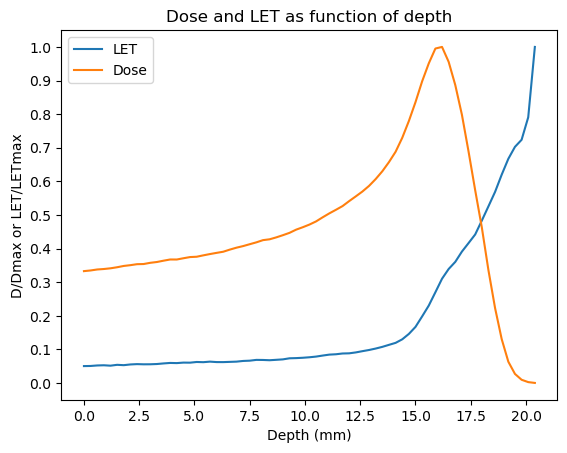

In [124]:
#Plot lineprofile as function of depth
plt.plot(ydata, letdata, label='LET')
plt.plot(ydata, dosedata, label='Dose')
plt.title('Dose and LET as function of depth')
plt.xlabel('Depth (mm)')
plt.ylabel('D/Dmax or LET/LETmax')
plt.yticks(np.arange(0, 1.1, 0.1))
plt.legend()

### Generate LET map of the cell layer

Done for the ROI 'Cell Layer'

In [64]:
path = r"C:\Users\bhaan\Downloads\Unrestricted beam plan - LET data and RTStruct\roi_let_dose_celllayer.csv"
data_cells = pd.read_csv(path)
print(data_cells.loc[35:45])

       x_mm    y_mm    z_mm  LET_keV_per_um  Dose_GyRBE
35   2.4596 -82.529 -231.95        1.918017    0.790109
36   2.7596 -82.529 -231.95        1.850595    0.778942
37 -11.3404 -82.229 -231.95        1.864039    0.768653
38 -11.0404 -82.229 -231.95        1.890451    0.766632
39 -10.7404 -82.229 -231.95        1.884356    0.774142
40 -10.4404 -82.229 -231.95        1.861265    0.766058
41 -10.1404 -82.229 -231.95        1.888530    0.769479
42  -9.8404 -82.229 -231.95        1.870184    0.776992
43  -9.5404 -82.229 -231.95        1.872689    0.769254
44  -9.2404 -82.229 -231.95        1.886584    0.772514
45  -8.9404 -82.229 -231.95        1.839106    0.774941


In [68]:
#Due to the fineness of the dose grid the cell layer also has multiple depth values
#I'll map the first one
slice = data_cells[data_cells['y_mm']==data_cells['y_mm'].unique()[0]]

#Set up image array
x_vals = slice['x_mm'].unique()
z_vals = slice['z_mm'].unique()
imarray = np.zeros([int(len(z_vals)), int(len(x_vals))])

#Populate image array with LET values
for i in slice.index.tolist():
    datapoint = slice.loc[i]
    x = datapoint.x_mm
    z = datapoint.z_mm
    let = datapoint.LET_keV_per_um

    x_index = np.where(x_vals == x)
    z_index = np.where(z_vals == z)

    imarray[z_index, x_index] = let

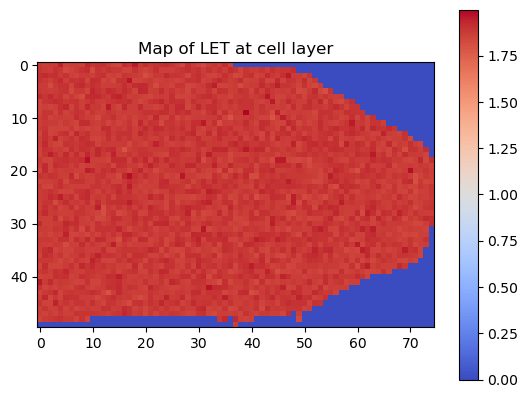

In [128]:
#Regular plot
plt.imshow(imarray,cmap='coolwarm')
plt.title('Map of LET at cell layer')
plt.colorbar()

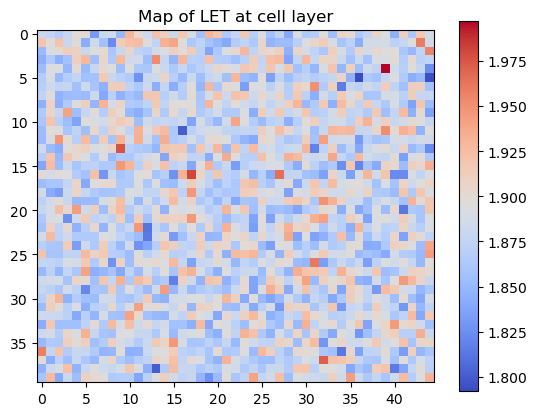

In [89]:
#Crop images to be only inside the cell flask --> highlight differences
imarray_crop = imarray[5:45, 0:45]

#Regular plot
plt.imshow(imarray_crop,cmap='coolwarm')
plt.title('Map of LET at cell layer')
plt.colorbar()

### Obtain dose and LET in POI

POI = dose point at cells, useful for modelling

In [120]:
sinfo = dcm.dcmread(r"C:\Users\bhaan\Downloads\Unrestricted beam plan - LET data and RTStruct\RS1.2.752.243.1.1.20250929144022326.2300.24261.dcm")

#Find the ROI that represents the point
for i in range(len(sinfo.ROIContourSequence)):
    if sinfo.ROIContourSequence[i].ContourSequence[0].ContourGeometricType == 'POINT':
        #This is the point, store the coordinates
        coords = np.array(sinfo.ROIContourSequence[i].ContourSequence[0].ContourData)

print(coords)

[  44.76693  -82.14333 -261.     ]


In [121]:
#I override the location of coords for now bc the dose point is not in the water phantom area
coords = np.array([-6.540400,-107.429000,-236.750000])

In [122]:
#Find point in LET data
pointdata = data_waterphantom[(data_waterphantom['x_mm']==coords[0]) & (data_waterphantom['y_mm']==coords[1]) & (data_waterphantom['z_mm']==coords[2])]
print('LET in POI: ' + str(pointdata['LET_keV_per_um'].values[0]) + ' keV/um')
print('Dose in POI: ' + str(pointdata['Dose_GyRBE'].values[0]) + ' Gy')

LET in POI: 2.597875 keV/um
Dose in POI: 0.391017 Gy
